In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.feature_selection import f_classif, chi2
from scipy.stats import spearmanr, chi2_contingency, pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import math
import warnings
warnings.filterwarnings('ignore')

In [49]:
df=pd.read_csv(r"harry_potter_1000_students.csv")
df.shape

(1000, 10)

In [50]:
def data_info(data):
    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]



    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,})
    return info_df
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,Blood Status,object,"[Half-blood, Pure-blood, Muggle-born]",3,0,0.0
1,Bravery,int64,"[7, 6, 2, 3, 1, 4, 5, 9, 10, 8]",10,0,0.0
2,Intelligence,int64,"[7, 3, 5, 6, 1, 4, 2, 9, 10, 8]",10,0,0.0
3,Loyalty,int64,"[7, 1, 6, 3, 5, 4, 2, 8, 10, 9]",10,0,0.0
4,Ambition,int64,"[7, 2, 5, 3, 4, 1, 6, 9, 10, 8]",10,0,0.0
5,Dark Arts Knowledge,int64,"[1, 4, 2, 3, 0, 5, 10, 7, 9, 8]",10,0,0.0
6,Quidditch Skills,int64,"[5, 7, 6, 9, 8, 4, 10, 3, 1, 0]",11,0,0.0
7,Dueling Skills,int64,"[7, 9, 10, 8, 3, 1, 4, 2, 5, 6]",10,0,0.0
8,Creativity,int64,"[7, 6, 2, 1, 5, 4, 3, 9, 10, 8]",10,0,0.0
9,House,object,"[Slytherin, Ravenclaw, Hufflepuff, Gryffindor]",4,0,0.0


In [51]:
df.drop("Blood Status",inplace=True,axis=1)
df.drop("Dark Arts Knowledge",inplace=True,axis=1)
df.drop("Quidditch Skills",inplace=True,axis=1)
df.drop("Dueling Skills",inplace=True,axis=1)

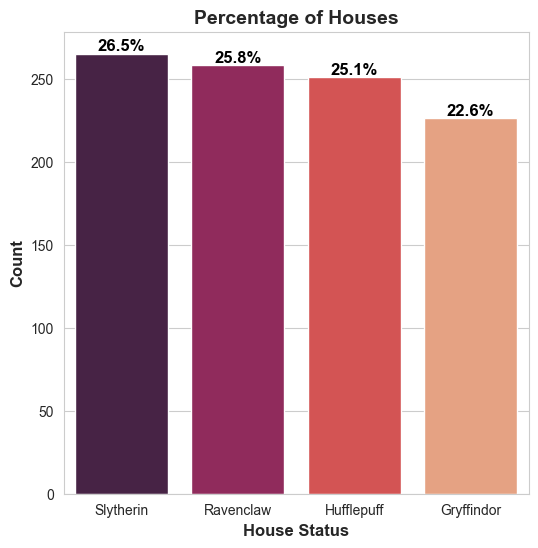

In [52]:
sns.set_style("whitegrid")
churn_counts = df["House"].value_counts(normalize=True)*100

plt.figure(figsize=(6, 6))
ax = sns.barplot(x=churn_counts.index, y=df["House"].value_counts(), palette="rocket")

plt.title("Percentage of Houses", fontsize=14, fontweight='bold')
plt.xlabel("House Status", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for p, percentage in zip(ax.patches, churn_counts.values):
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')
plt.show()

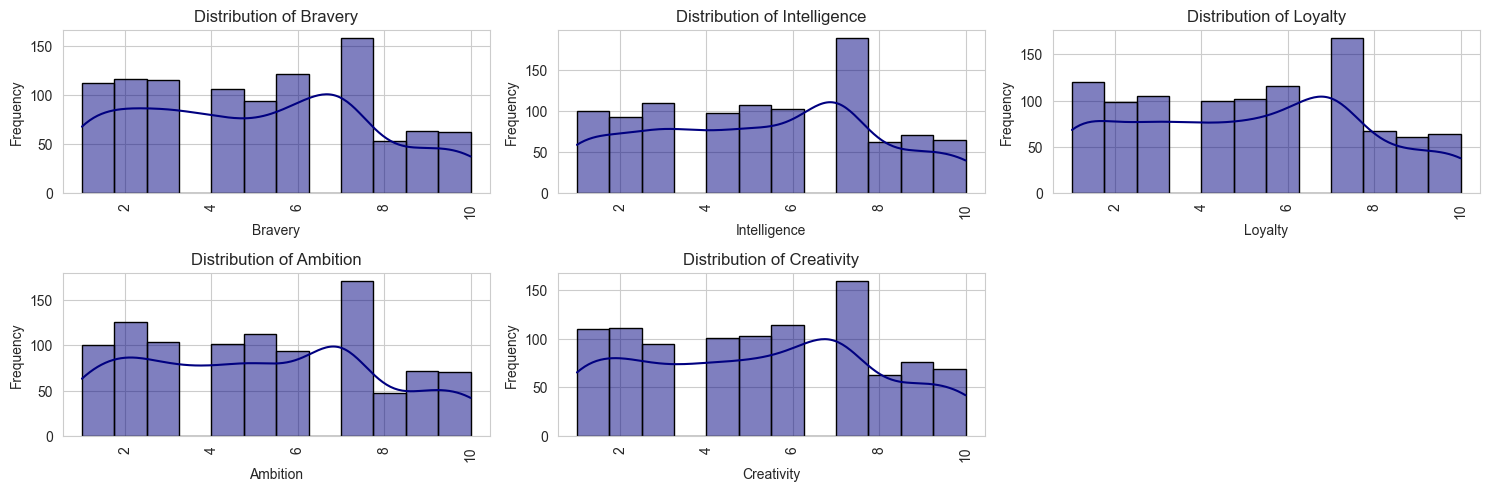

In [53]:
num =df.select_dtypes(include=['int64']).columns
fig, axes = plt.subplots(3, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num) :
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="navy", edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

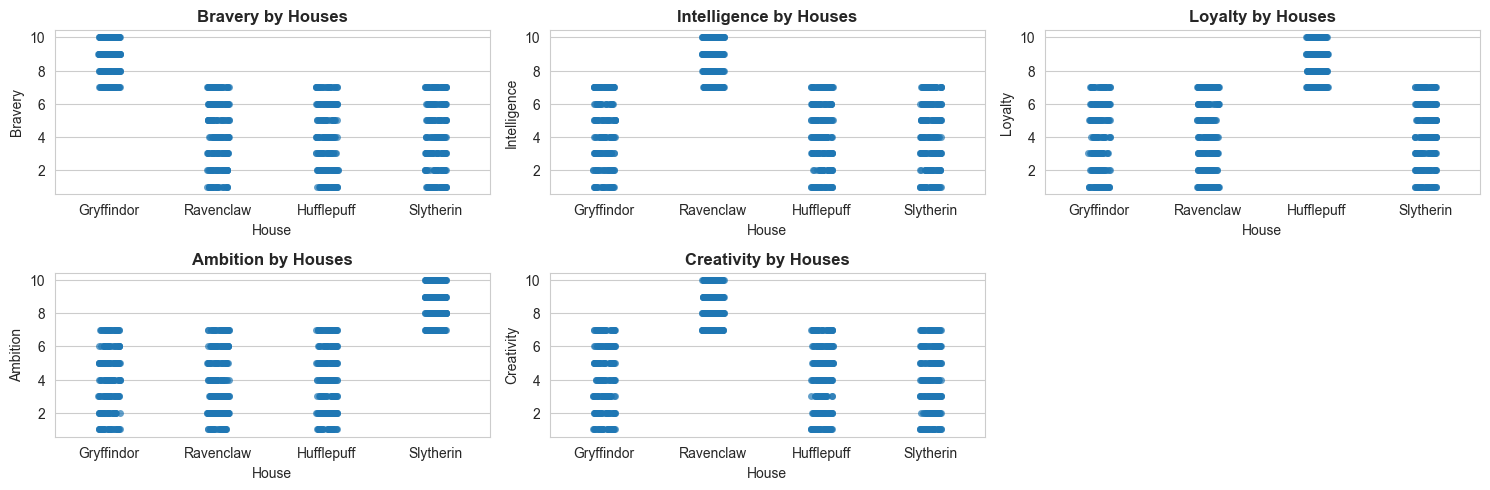

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num):
    sns.stripplot(
        x="House",
        y=col,
        data=df,
        jitter=True,
        alpha=0.7,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Houses", fontweight="bold")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [55]:
df.duplicated().sum()

np.int64(17)

In [56]:
df.drop_duplicates(inplace = True)

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
X=df.drop(["House"],axis=1)
y=df["House"]

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [59]:
le=LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [60]:
x = x_train[num]
y = y_train
f_values, p_values = f_classif(x, y)
anova_df = pd.DataFrame({
    'Feature': num,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print(anova_df)

        Feature     F-Score        P-Value
3      Ambition  334.235591  1.274641e-139
4    Creativity  316.271399  2.026729e-134
2       Loyalty  285.643841  3.624277e-125
0       Bravery  282.638195  3.125711e-124
1  Intelligence  277.945058  9.255729e-123


In [61]:
log_reg = LogisticRegression(random_state=42)

log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)
y_pred_train = log_reg.predict(x_train)

print(classification_report(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       1.00      0.95      0.98        44
           2       0.97      0.98      0.98        63
           3       0.98      0.98      0.98        44

    accuracy                           0.97       197
   macro avg       0.98      0.97      0.97       197
weighted avg       0.97      0.97      0.97       197

Train Accuracy: 0.9758269720101781
Test Accuracy: 0.9746192893401016


In [62]:
import pickle

with open("hogwarts_model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

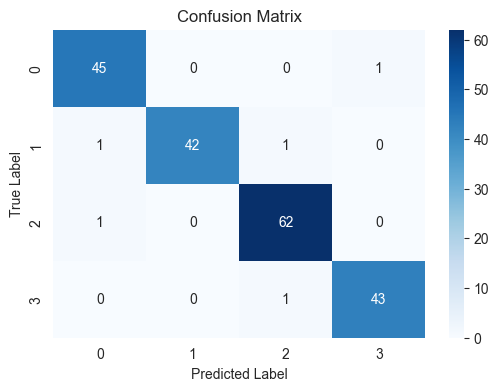

In [63]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

lr = LogisticRegression(
     solver="lbfgs", max_iter=1000, n_jobs=None
)
lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", lr)
])
lr_pipe.fit(x_train, y_train)

feat_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()

lr_model = lr_pipe.named_steps["model"]
classes = lr_model.classes_
coef_mat = lr_model.coef_

coef_df = pd.DataFrame(coef_mat, index=classes, columns=feat_names).T
coef_df.reset_index(inplace=True)
coef_df.rename(columns={"index": "feature"}, inplace=True)
print(coef_df)


             feature         0         1         2         3
0       num__Bravery  3.332025 -1.316483 -0.981205 -1.034337
1  num__Intelligence -0.770622 -0.677599  2.423483 -0.975262
2       num__Loyalty -1.320179  3.477043 -0.847837 -1.309027
3      num__Ambition -1.139267 -1.197753 -0.982696  3.319715
4    num__Creativity -0.684834 -0.941308  2.507194 -0.881052


In [65]:
my_sample = pd.DataFrame([{
         'Bravery': 3,
          'Intelligence':2,
          'Loyalty':5,
          'Ambition': 3,
          'Creativity': 10
}])

print(log_reg.predict(my_sample))

[2]
